In [15]:
import pandas as pd
import numpy as np
import itertools
import time
import random
import warnings
warnings.filterwarnings('ignore')
import math
import sys
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from scipy.stats import normaltest
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Dropout

In [16]:
df=pd.read_csv('/workspaces/Stock-Market-Project/stock_data.csv')
df

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    str    
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), str(1)
memory usage: 17.2 KB


In [18]:
df.isna().sum()

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64

In [20]:
print(df.columns)

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='str')


In [23]:
data = df['Stock_1'].values[-180:-60]
test = df['Stock_1'].values[-60:]

In [24]:
X = df[-180:-60]
X.reset_index(drop=True, inplace=True)

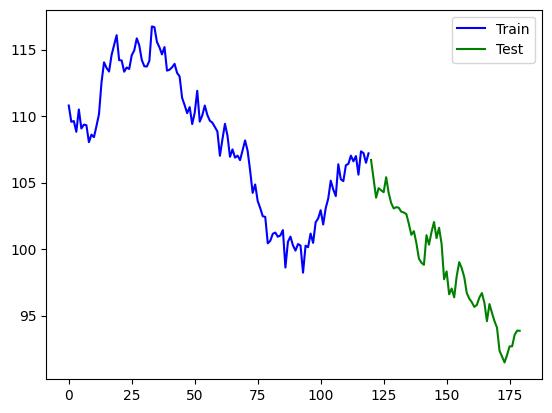

In [25]:
plt.plot(data, c='b', label='Train')
plt.plot(len(data)+np.array(range(len(test))), test, c='g', label='Test')
plt.legend()

plt.show()

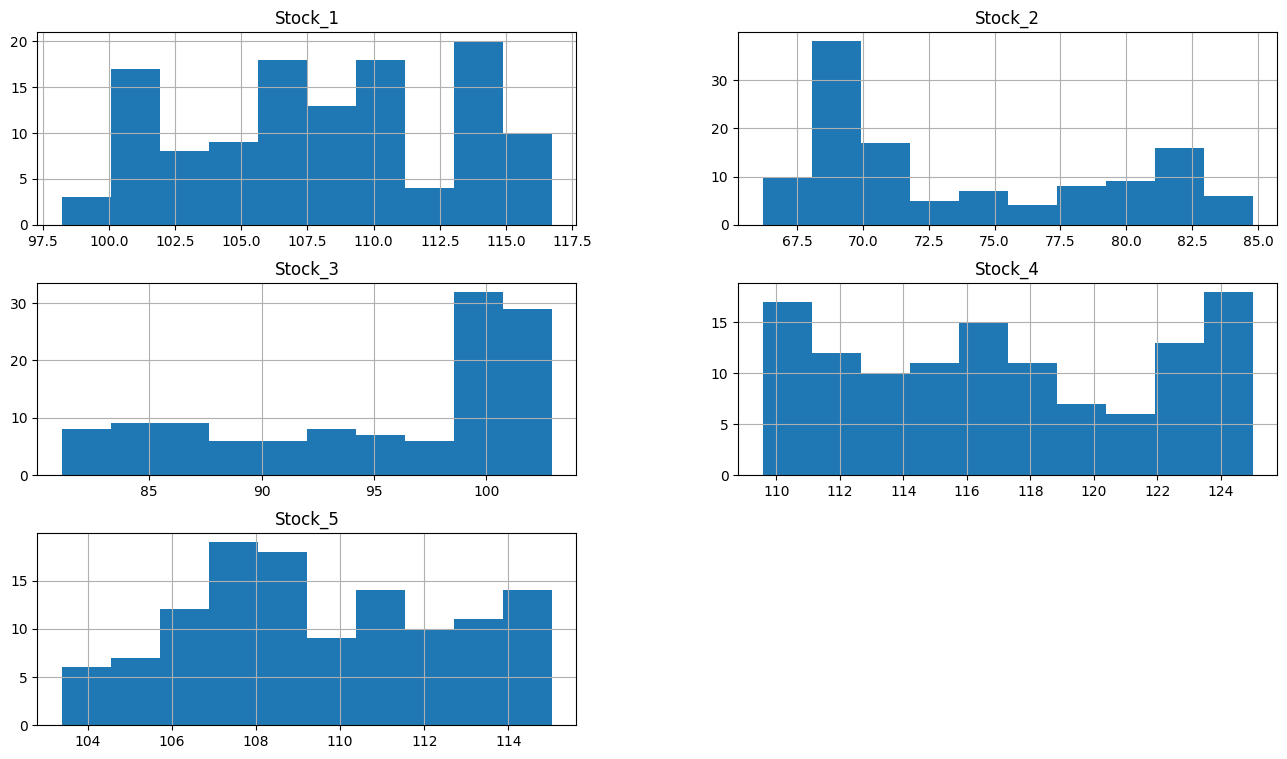

In [26]:
X.hist(figsize=(16,9))

plt.show()

In [27]:

def ts_diagnostics(y, lags=None, title=''):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # weekly moving averages (5 day week -> 2week window)
    roll_mean = y.rolling(window=10).mean()
    roll_std = y.rolling(window=10).std()

    plt.figure(figsize=(16, 10))
    layout = (3, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
    acf_ax = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))
    qq_ax = plt.subplot2grid(layout, (2, 0))
    hist_ax = plt.subplot2grid(layout, (2, 1))

    # time series plot
    y.plot(ax=ts_ax)
    roll_mean.plot(ax=ts_ax, color='crimson', label='rolling-mean');
    roll_std.plot(ax=ts_ax, color='darkslateblue', label='rolling-std');
    ts_ax.legend(loc='best')
    ts_ax.set_title(title, fontsize=24);

    # acf and pacf
    plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
    plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

    # qq plot
    sm.qqplot(y, line='s', ax=qq_ax)
    qq_ax.set_title('QQ Plot')

    # hist plot
    y.plot(ax=hist_ax, kind='hist', bins=25);
    hist_ax.set_title('Histogram');
    plt.tight_layout();
    plt.show()

    # perform Augmented Dickey Fuller test
    print('Dickey-Fuller test:')
    dftest = adfuller(y, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['test statistic', 'p-value', '# of lags', '# of observations'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

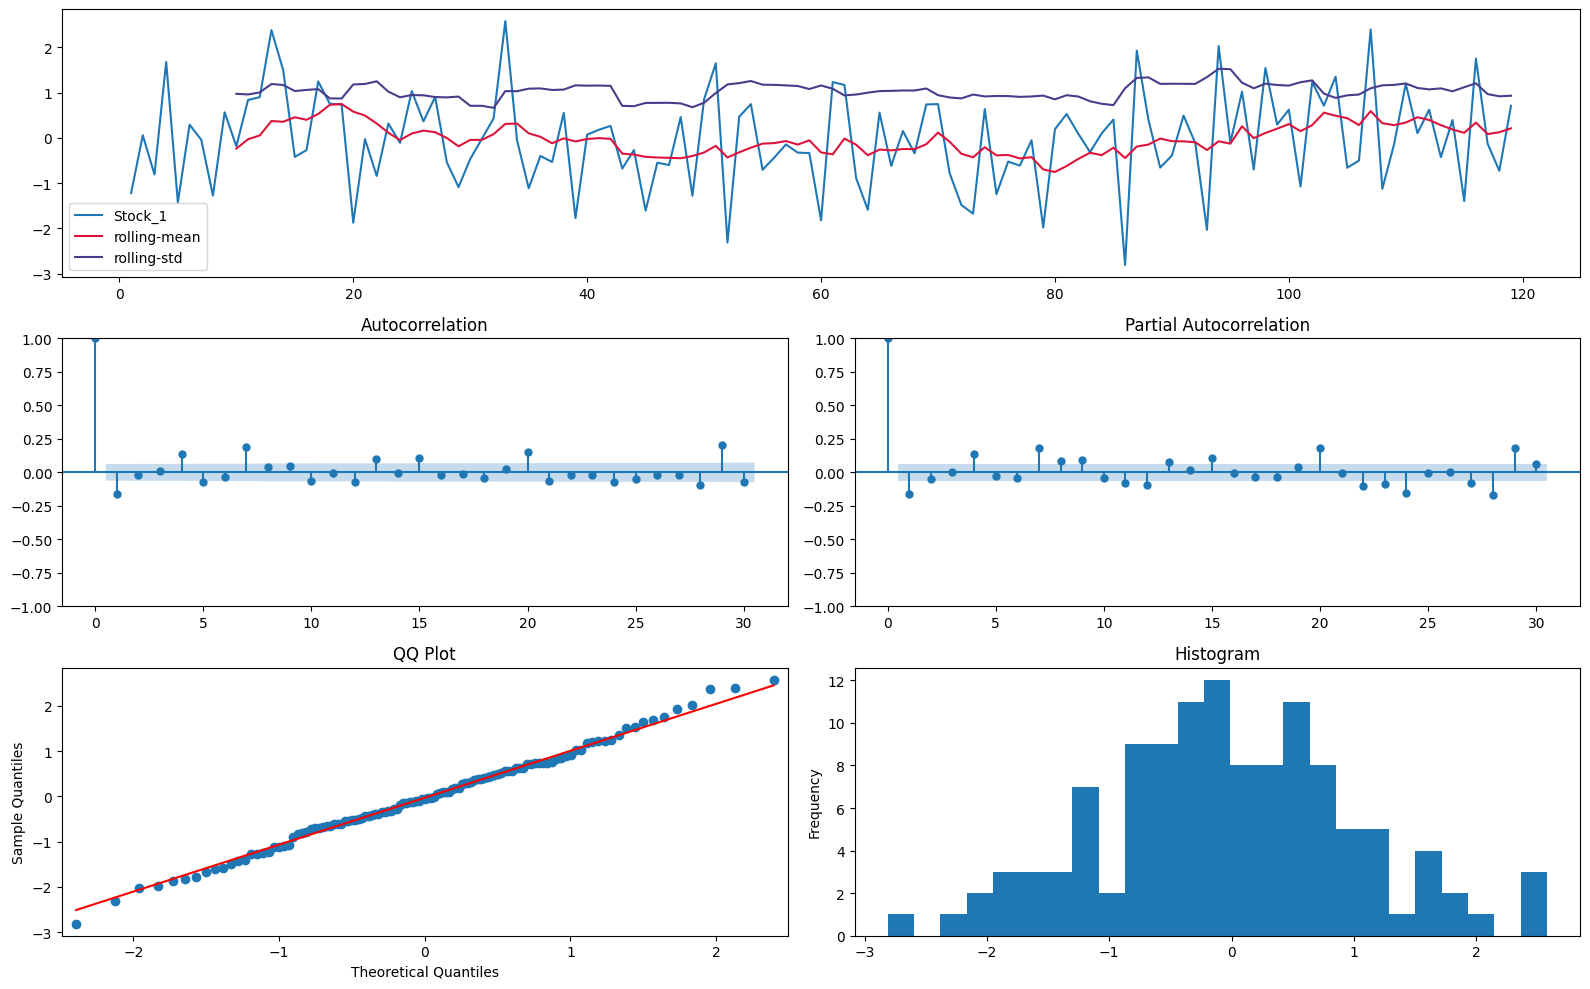

Dickey-Fuller test:
test statistic         -1.270977e+01
p-value                 1.036231e-23
# of lags               0.000000e+00
# of observations       1.180000e+02
Critical Value (1%)    -3.487022e+00
Critical Value (5%)    -2.886363e+00
Critical Value (10%)   -2.580009e+00
dtype: float64


In [31]:
ts_diagnostics(X['Stock_1'].diff().dropna(), lags=30)

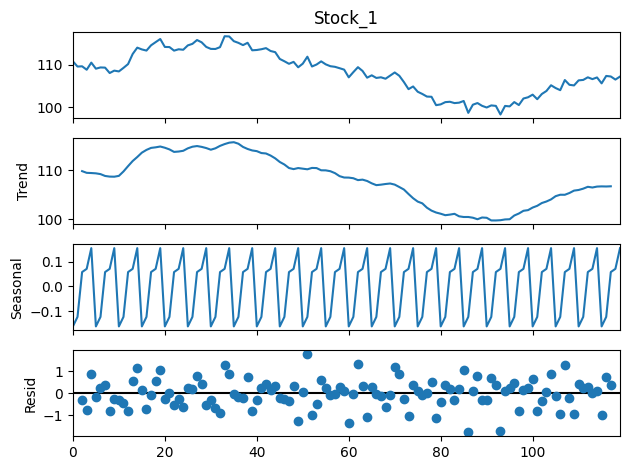

In [41]:
res = seasonal_decompose(X['Stock_1'], model='additive', period=5) 
res.plot()

plt.show()

In [44]:
%%time
### grid search sarima params
model_choice = {}
p = q = range(0, 5)
d = [1]
season = 5
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(i, j, k, season) for i, j, k in pdq]
for order, season in itertools.product(pdq, seasonal_pdq):
    try:
        model = sm.tsa.statespace.SARIMAX(data,
                  order=order,
                  seasonal_order=season).fit(disp=0, method='nm')
    except:
        continue
    model_choice[(order, season)] = mse(data[-14:], model.fittedvalues[-14:])
order, season = min(model_choice, key=model_choice.get)

CPU times: user 3min 2s, sys: 1.15 s, total: 3min 3s
Wall time: 1min 42s


In [43]:
order, season = ((4, 1, 1), (4, 1, 4, 5))
order, season

((4, 1, 1), (4, 1, 4, 5))

In [45]:
%%time
clf_sar = sm.tsa.statespace.SARIMAX(data, 
                                    trend='n',
                                    order=order,
                                    seasonal_order=season
                                ).fit(disp=0, method='lbfgs')

CPU times: user 5.48 s, sys: 8.33 ms, total: 5.49 s
Wall time: 5.53 s


In [46]:
clf_sar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                         
=================================================================================================
Dep. Variable:                                         y   No. Observations:                  120
Model:             SARIMAX(4, 1, 1)x(4, 1, [1, 2, 3], 5)   Log Likelihood                -167.574
Date:                                   Thu, 30 Apr 2026   AIC                            361.148
Time:                                           08:26:26   BIC                            396.718
Sample:                                                0   HQIC                           375.584
                                                   - 120                                         
Covariance Type:                                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5178      0.341      1.519      0.129      -0.150       1.186
ar.L2          0.0740      0.126      0.585      0.558      -0.174       0.322
ar.L3          0.1001      0.140      0.717      0.473      -0.173       0.373
ar.L4          0.0945      0.165      0.571      0.568      -0.230       0.419
ma.L1         -0.6625      0.326     -2.035      0.042      -1.301      -0.025
ar.S.L5       -1.4440      1.695     -0.852      0.394      -4.766       1.878
ar.S.L10      -1.0954      1.287     -0.851      0.395      -3.618       1.428
ar.S.L15      -0.8544      1.184     -0.722      0.470      -3.174       1.465
ar.S.L20      -0.2601      0.606     -0.429      0.668      -1.447       0.927
ma.S.L5        0.4013      1.699      0.236      0.813      -2.928       3.731
ma.S.L10      -0.2732      0.638     -0.429      0.668      -1.523       0.977
ma.S.L15       0.1855      0.380      0.488      0.625      -0.559       0.930
sigma2         1.0381      0.170      6.100      0.000       0.705       1.372
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.24
Prob(Q):                              0.98   Prob(JB):                         0.89
Heteroskedasticity (H):               0.94   Skew:                             0.10
Prob(H) (two-sided):                  0.86   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

NormaltestResult(statistic=array([2.61446458]), pvalue=array([0.27056787]))


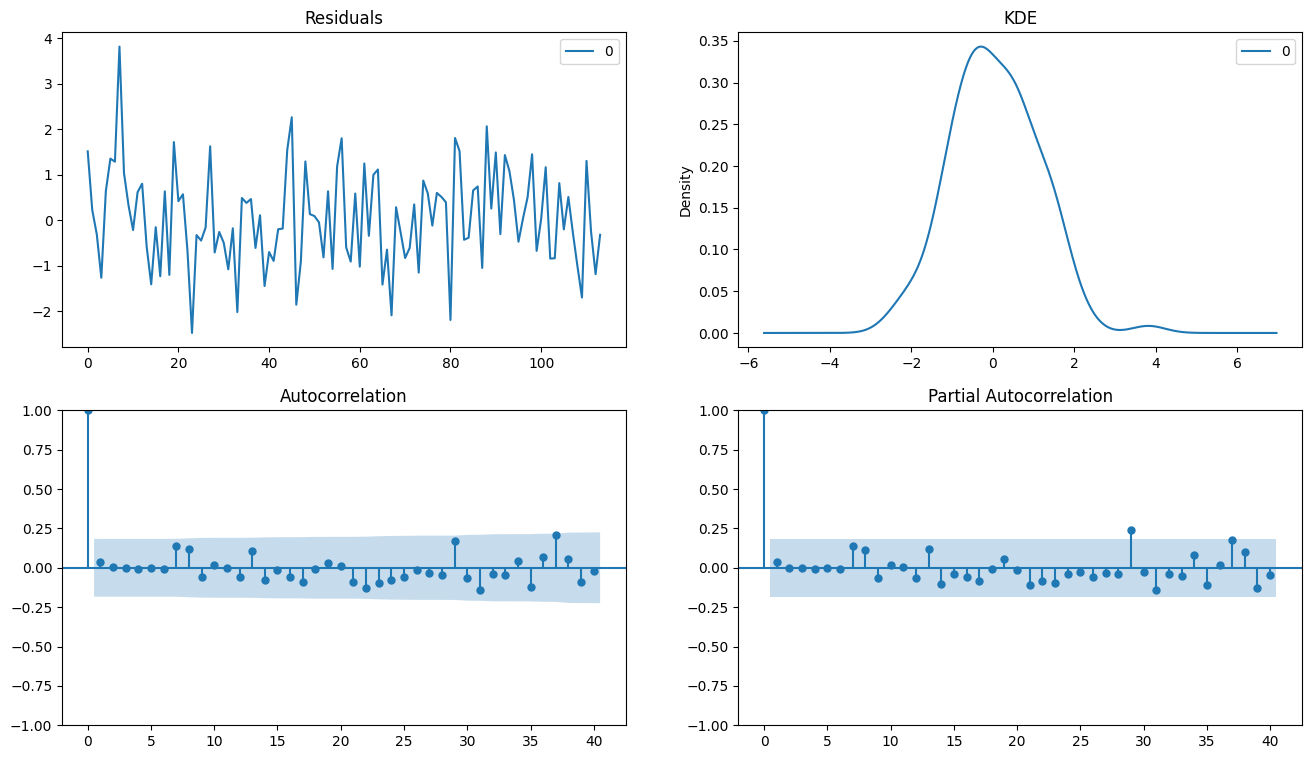

,0
count,114.000000
mean,0.052887
std,1.066413
min,-2.473339
25%,-0.670979
50%,-0.080527
75%,0.653362
max,3.815007


In [47]:
resid = pd.DataFrame(clf_sar.resid[6:])
print(normaltest(resid))

plt.figure(figsize=(16, 9))
layout = (2, 2)
res_ax = plt.subplot2grid(layout, (0, 0))
kde_ax = plt.subplot2grid(layout, (0, 1))
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

resid.plot(ax=res_ax, title='Residuals')
resid.plot(ax=kde_ax, kind='kde', title='KDE')
plot_acf(resid, lags=40, ax=acf_ax)
plot_pacf(resid, lags=40, ax=pacf_ax)

plt.show()

resid.describe()

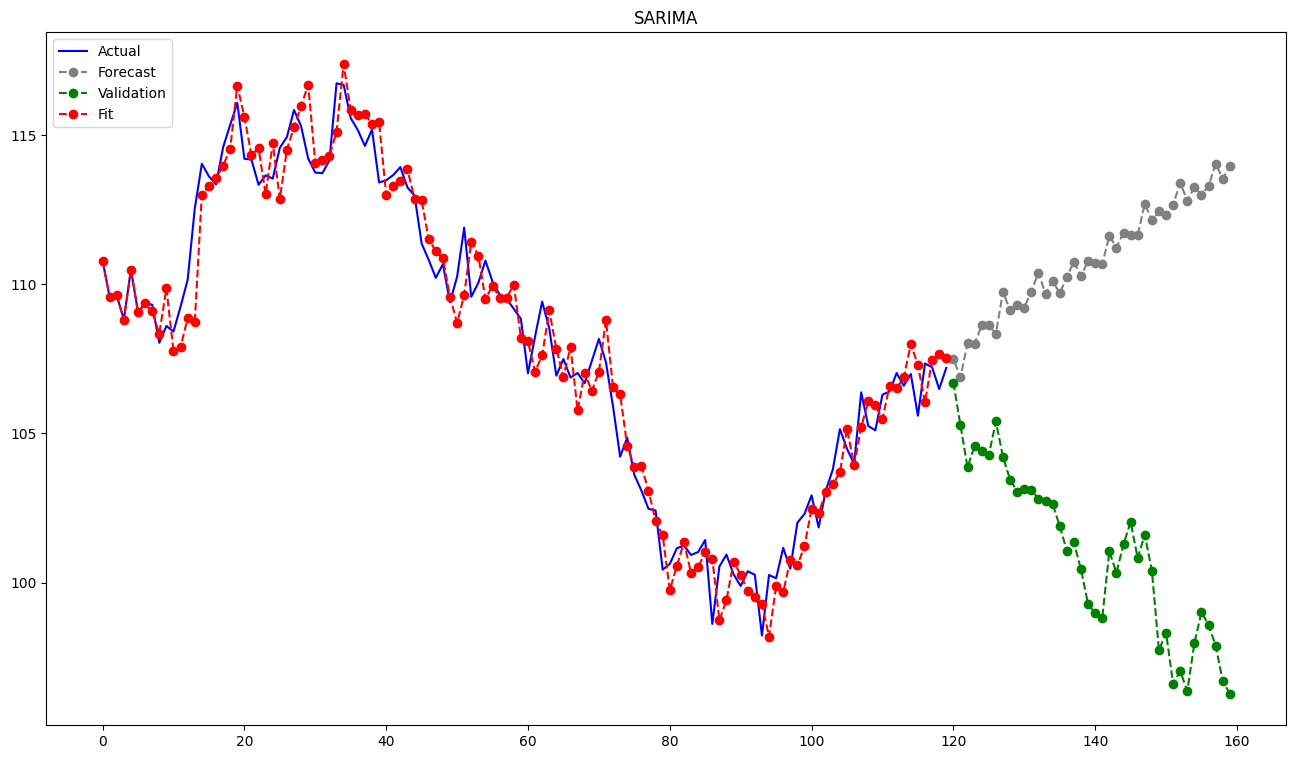

In [49]:
pred_period = 40
x = [i for i in range(len(data) -1, len(data) + pred_period)]
fcast = [clf_sar.fittedvalues[-1]]
for i in clf_sar.forecast(pred_period):
    fcast.append(i)

plt.figure(figsize=(16,9))
plt.plot(X['Stock_1'], 'blue', label = 'Actual')
fit_y = [data[i] if i<7 else clf_sar.fittedvalues[i] 
         for i in range(0, len(data))]
plt.plot(x, fcast, 'o--', c='grey', label ='Forecast')
plt.plot(x[1:], test[:pred_period], 'o--', c='green', label ='Validation')
plt.plot(fit_y, 'o--', color='red', label = 'Fit')
plt.legend(loc=2)
plt.title('SARIMA')

plt.show()

In [50]:
def split_sequence(seq, n_steps):
    X, y = list(), list()
    for i in range(len(seq)):
        end = i + n_steps
        if end > len(seq)-1:
            break
        seq_x, seq_y = seq[i:end], seq[end]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [53]:
seq = X['Stock_1'].values
n_steps = 5
X_train, y_train = split_sequence(seq, n_steps)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [54]:
#define model (Vanilla LSTM)
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(n_steps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
print(model.summary())
model.fit(X_train, y_train, epochs=600, verbose=0)

E0000 00:00:1777537898.742510    2908 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

None


MSE =  1.980274887511901


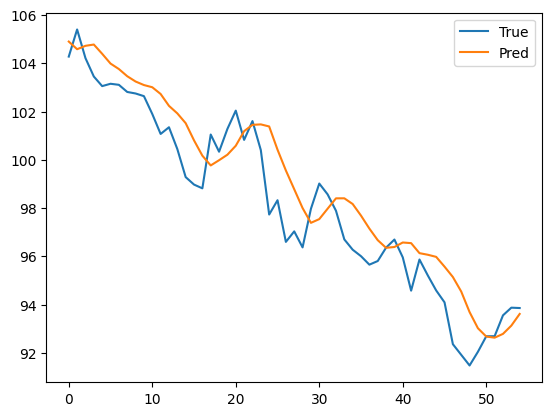

In [55]:
#prediction (Vanilla LSTM)
X_test, y_test = split_sequence(test, n_steps)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
yhat = model.predict(X_test, verbose=0)
print('MSE = ', mse(y_test, yhat))

plt.plot(y_test, label='True')
plt.plot(yhat, label='Pred')
plt.legend()

plt.show()

In [56]:
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, 
               input_shape=(n_steps, 1)))
model.add(LSTM(64, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
print(model.summary())
model.fit(X_train, y_train, epochs=600, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

None


MSE =  4.024472024953186


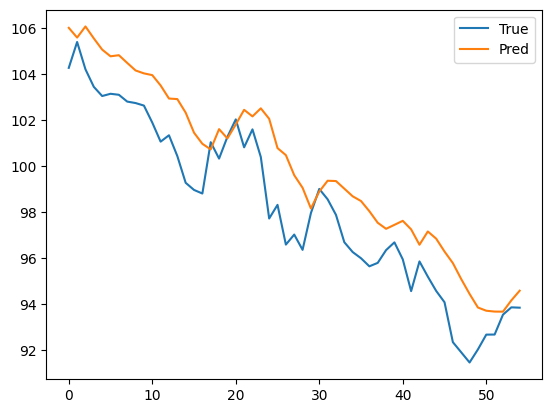

In [57]:
X_test, y_test = split_sequence(test, n_steps)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
yhat = model.predict(X_test, verbose=0)
print('MSE = ', mse(y_test, yhat))

plt.plot(y_test, label='True')
plt.plot(yhat, label='Pred')
plt.legend()

plt.show()

In [60]:
%%time
data = X['Stock_1'].values
alpha = np.linspace(0.0, 0.9, 12)
beta  = np.linspace(0.0, 0.9, 12)
gamma = np.linspace(0.0, 0.9, 12)
seasons = [7]
params = {}
mse_range = -15
for i, j, k in itertools.product(alpha, beta, gamma):
    for s in seasons:
        try:
            fit1 = ExponentialSmoothing(data,seasonal_periods=s,
                                        damped = True, trend='add',
                                        seasonal='add').fit(
                                        smoothing_level=i, smoothing_slope=j,
                                        smoothing_seasonal=k, remove_bias=True)
        except:
            continue
        params[(i, j, k, s)] = mse(data[mse_range:-1],
                                    fit1.fittedvalues[mse_range+1:])

if not params:
    s = 5; alpha = 0.1; beta = 0.1; gamma = 0.4
else:
    alpha, beta, gamma, s = min(params, key=params.get)

CPU times: user 55.1 s, sys: 131 ms, total: 55.2 s
Wall time: 31.8 s


In [61]:
%%time
clf = ExponentialSmoothing(data, damped = True,
                           seasonal_periods=s, trend='add',
                           seasonal='add').fit(
                           smoothing_level=alpha, smoothing_slope=beta,
                           smoothing_seasonal=gamma, remove_bias=True)

CPU times: user 79.8 ms, sys: 879 μs, total: 80.7 ms
Wall time: 262 ms


In [62]:
clf.params

{'smoothing_level': np.float64(0.9),
 'smoothing_trend': np.float64(0.32727272727272727),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': np.float64(0.8),
 'initial_level': np.float64(110.59888306833504),
 'initial_trend': np.float64(-0.6064987274607097),
 'initial_seasons': array([ 0.62626993,  0.19460974,  0.01876757, -0.26275394,  0.08884813,
         0.42297097,  0.58034563]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': True}

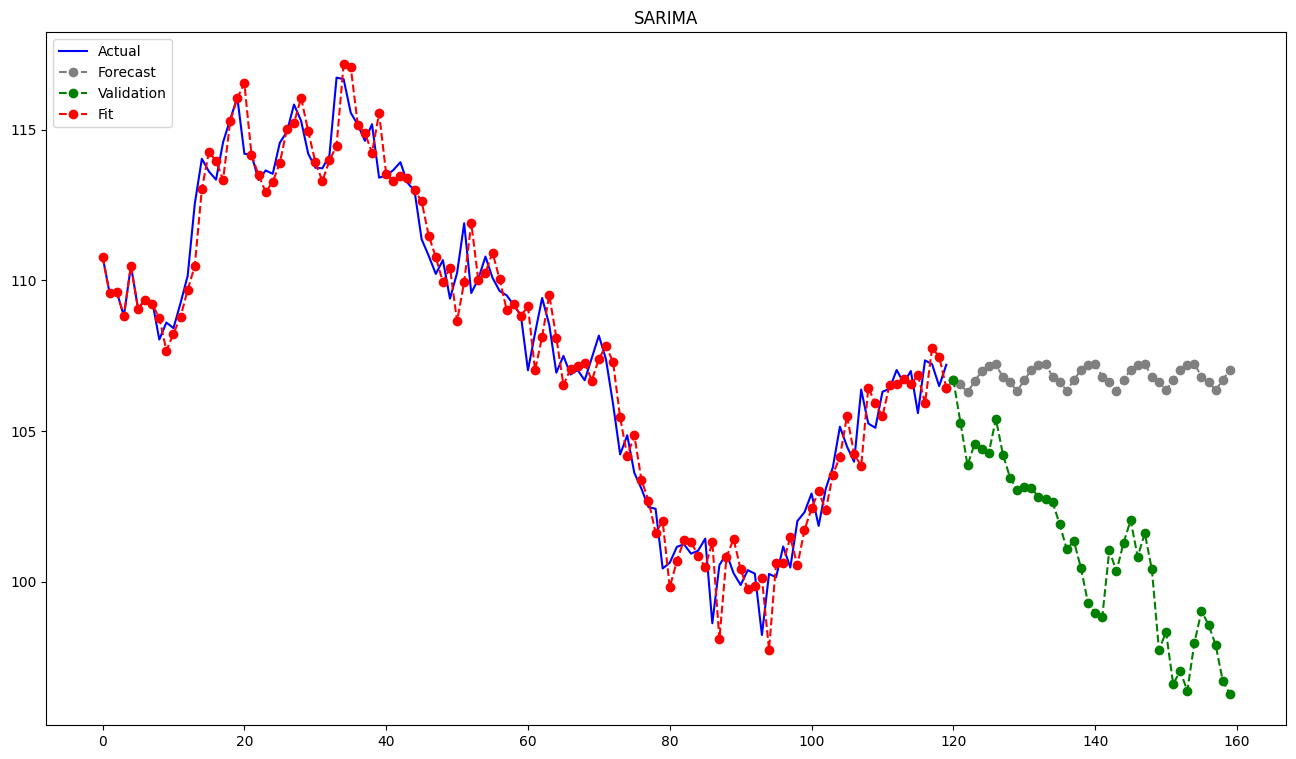

In [63]:
pred_period = 40
x = [i for i in range(len(data)-1, len(data) + pred_period)]
fcast = [clf.fittedvalues[-1]]
for i in clf.forecast(pred_period):
    fcast.append(i)
#s, d = gpf.forecastOutliers(X, metric, clf_sar, 'SARIMAX')
plt.figure(figsize=(16,9))
plt.plot(data, 'blue', label = 'Actual')
fit_y = [data[i] if i<7 else clf.fittedvalues[i] 
         for i in range(0, len(data))]
plt.plot(x, fcast, 'o--', c='grey', label ='Forecast')
plt.plot(x[1:], test[:pred_period], 'o--', c='green', label ='Validation')
plt.plot(fit_y, 'o--', color='red', label = 'Fit')
#plt.xticks(df.index[-120:], xt_cls[-120:], rotation = 90)
# plt.gca().set_yticklabels(['{:.3f}%'.format(x*100) 
#                        for x in plt.gca().get_yticks()])
plt.legend(loc=2)
plt.title('SARIMA')

plt.show()